In [1]:
import sys

#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent))
import config
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, BaseCrossValidator
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from src.cleaning import clean
from src.feature_engineering import build_panel_data

In [ ]:
df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)

#train/test split
train = panel_data[panel_data['Year'] <= 2023]
test = panel_data[panel_data['Year'] == 2024]
train_X = train[config.FEATURES]
train_y = train['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']


clf = HistGradientBoostingClassifier(
    random_state=42, 
    learning_rate = config.FINAL_PARAMS['learning_rate'],
    max_depth = config.FINAL_PARAMS['max_depth'],
    max_iter = config.FINAL_PARAMS['max_iter'],
    l2_regularization = config.FINAL_PARAMS['l2_regularization']
    
)

clf.fit(train_X,train_y)

preds = clf.predict(test_X)
probs = clf.predict_proba(test_X)[:,1]
scores_dict =  {
        "f1":        f1_score(test_y, preds),
        "recall":    recall_score(test_y, preds),
        "accuracy":  accuracy_score(test_y, preds),
        "precision": precision_score(test_y, preds),}
print(scores_dict)

clf_baseline = DummyClassifier(strategy="most_frequent")
clf_baseline.fit(train_X, train_y)
baseline_accuracy = clf_baseline.score(test_X, test_y)
print(f"The classifier has an accuracy of {scores_dict['accuracy']*100:.2f}%")
print(f'The model gives a {((scores_dict['accuracy'] - baseline_accuracy) *100):.2f}% improvement in accuracy compared to a majority class baseline of {baseline_accuracy *100:.2f}%.')

An equal misclassification cost assumption was made (as specified in `04_feature_selection.ipynb`) which makes accuracy the primary evaluation metric. There is a 12% improvement in accuracy compared to a majority class baseline. 

The model has high recall: it catches most churners (84%) at the cost of precision. 39% identified by the model as churners actually stay. This can also be seen in the confusion matrix below.

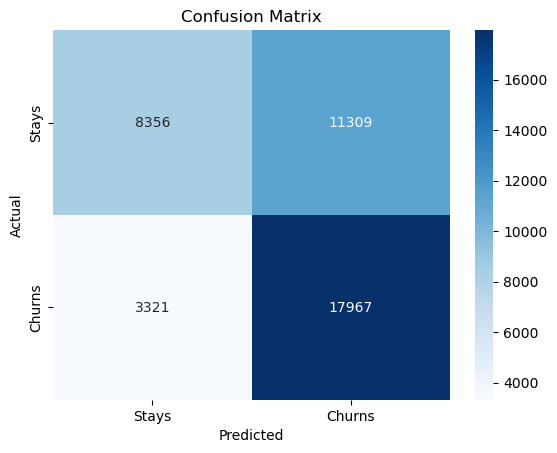

In [17]:
cm = confusion_matrix(test_y, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

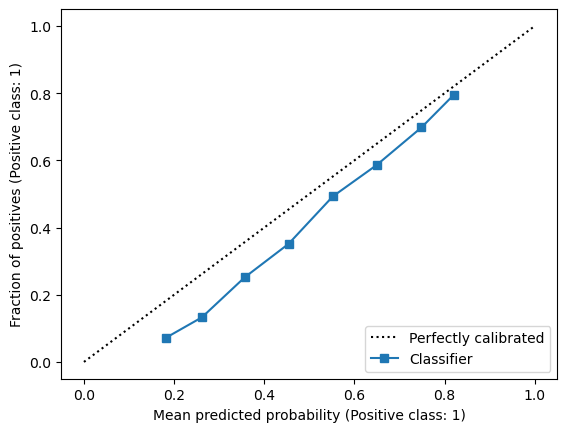

In [23]:
CalibrationDisplay.from_predictions(test_y, probs, n_bins=10)
plt.show()

The probability of churn is consistently overestimated by the model. This is consistent with the high recall of the model.

### Decision Threshold for Retention Intervention

The optimal threshold $p = t^*$ above which retention interventions should be applied can be determined by examining expected profit. 
The retention intervention takes the form of a half-price one-on-one coaching session if the lifter signs up for the next year's membership. The net cost of each coaching session to the federation is then
$$C = C_{\text{run session}} - \frac{1}{2} \text{Price}_{\text{session}}$$

and the expected revenue is then $$\text{revenue} =  P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i)  \cdot V$$
where:
- $V$ is the value of a retained lifter, assumed equal across lifters
- $C$ is the net cost of the coaching session to the federation
- $t$ is the intervention threshold
- $N_{p > t}$ is the number of lifters with predicted churn probability above $t$
- $p_i$ is the predicted churn probability for lifter $i$
- $P(\text{stay} \mid \text{intervention})$ is the probability a lifter is retained given intervention, assumed constant across lifters and estimable via A/B test

$$t^* = \underset{t \in [0,1]}{\arg\max} \left[ P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i) \cdot V \right]$$

The optimal threshold $t^*$ maximises expected profit. Since the relationship between $t$ and profit depends on the empirical distribution of predicted probabilities, this would be found via searching over values of $t$ rather than analytically.


In [ ]:
put in limitations 
If this last assumption were relaxed, a lower threshold $t_0^*$ would be introduced, below which a retention intervention is unlikely to cause the lifter to renew their membership. And therefore interventions would be offered to lifters with $t_0^*<p<t*$ and the revenue formula would be adjusted accordingly.

$$\text{revenue} =  P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i)  \cdot V$$